In [1]:
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import math

from common import (
    CASE_NAMES,
    get_dataset_sort_key,
    INDEX_ORDER,
    index_colors,
    index_markers,
    transform_duckdb_index_name,
    transform_pgvector_index_name,
    apply_style,
    save_fig,
    qps_median_ci,
    format_dataset_title,
    PLOT_DPI,
    LABEL_FONTSIZE,
    TICK_FONTSIZE,
    TITLE_FONTSIZE,
    MARKER_SIZE,
    FONT_COLOR,
    TICK_FONTS_COLOR,
)

# Toggle to show/hide point ID annotations on scatter plots.
ANNOTATE_POINT_IDS = False

# Commit hash for the "256 embeddings/cluster" global IVF approach.
# Results from this approach are excluded — they belong in the dedicated
# Cohere filtered-search notebook that distinguishes global IVF variants.
_COMMIT_256_PER_CLUSTER = "9b47764"


def compute_qps(metrics: dict) -> tuple[float, float, float]:
    """Compute (median_qps, lo_err, hi_err) from serial_latencies via bootstrap."""
    latencies = metrics.get("serial_latencies")
    if not latencies:
        raise ValueError("serial_latencies is missing or empty in metrics")
    return qps_median_ci(latencies)


# ---------------------------------------------------------------------------
# 1. Load all result JSONs
#
# Blob results (PDXearch, VSS/HNSW) come from the _blob directory.
# Non-blob results (DuckDB flat / no index, pgvector) come from the
# regular (non-blob) directory.
# ---------------------------------------------------------------------------
records = []


def _process_duckdb_entry(entry, *, index_filter: str | None = None):
    """Process one DuckDB result entry and append to records.

    index_filter: 'FLAT' to only process flat results,
                  'EXTENSION' to skip flat, None for all.
    """
    metrics = entry["metrics"]
    task_cfg = entry["task_config"]
    db_cfg = task_cfg["db_config"]
    db_case_cfg = task_cfg["db_case_config"]
    case_cfg = task_cfg["case_config"]

    idx = db_case_cfg.get("index", "")
    if index_filter == "FLAT" and idx != "FLAT":
        return
    if index_filter == "EXTENSION" and idx == "FLAT":
        return

    db_label = json.loads(db_cfg.get("db_label", "{}"))
    global_version = db_label.get("global_version", None)

    # Skip "256 embeddings/cluster" global IVF results — they are only
    # relevant in the dedicated Cohere filtered-search comparison notebook.
    if global_version is not None and db_label.get("pdxearch") == _COMMIT_256_PER_CLUSTER:
        return

    index_name = transform_duckdb_index_name(db_case_cfg, global_version)

    _qps = compute_qps(metrics)

    records.append({
        "recall": metrics["recall"],
        "serial_qps": _qps[0],
            "serial_qps_lo": _qps[1],
            "serial_qps_hi": _qps[2],
        "index": index_name,
        "case_id": case_cfg["case_id"],
        "db_type": "DuckDB",
        "threads": db_cfg.get("duckdb_threads", 1),
            "source_file": str(path),
    })


# --- Blob results: PDXearch & VSS (HNSW) from the _blob directory ---------
duckdb_blob_results_dir = pathlib.Path("../experiments/results/index_search_blob/DuckDB")
duckdb_blob_json_files = sorted(
    p for p in duckdb_blob_results_dir.glob("*.json") if not p.name.startswith("muted_")
) if duckdb_blob_results_dir.exists() else []

for path in duckdb_blob_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        _process_duckdb_entry(entry, index_filter="EXTENSION")

# --- Non-blob results: DuckDB flat (no index) from the regular directory ---
duckdb_results_dir = pathlib.Path("../experiments/results/index_search/DuckDB")
duckdb_json_files = sorted(
    p for p in duckdb_results_dir.glob("*.json") if not p.name.startswith("muted_")
) if duckdb_results_dir.exists() else []

for path in duckdb_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        _process_duckdb_entry(entry, index_filter="FLAT")

# --- pgvector results from the regular directory ---------------------------
pgvector_results_dir = pathlib.Path("../experiments/results/index_search/pgvector")
pgvector_json_files = sorted(
    p for p in pgvector_results_dir.glob("*.json") if not p.name.startswith("muted_")
) if pgvector_results_dir.exists() else []

for path in pgvector_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]

        index_name = transform_pgvector_index_name(db_case_cfg)

        _qps = compute_qps(metrics)
        records.append({
            "recall": metrics["recall"],
            "serial_qps": _qps[0],
            "serial_qps_lo": _qps[1],
            "serial_qps_hi": _qps[2],
            "index": index_name,
            "case_id": case_cfg["case_id"],
            "db_type": "pgvector",
            "threads": db_case_cfg.get("max_parallel_workers", 1),
            "source_file": str(path),
        })

print(f"Loaded {len(records)} results from "
      f"{len(duckdb_json_files)} DuckDB (non-blob) files, "
      f"{len(duckdb_blob_json_files)} DuckDB (blob) files, "
      f"and {len(pgvector_json_files)} pgvector files")
records[:3]

Loaded 998 results from 700 DuckDB (non-blob) files, 865 DuckDB (blob) files, and 183 pgvector files


[{'recall': 0.4437,
  'serial_qps': 1659.981092815353,
  'serial_qps_lo': 11.627633086276091,
  'serial_qps_hi': 10.924243162445237,
  'index': 'DuckDB PDXearch (IVF, Row Group, F32)',
  'case_id': 502,
  'db_type': 'DuckDB',
  'threads': 14,
  'source_file': '../experiments/results/index_search_blob/DuckDB/result_20260317_duckdbpdxearch_Performance1024D1200K_20-42-49_duckdb.json'},
 {'recall': 0.6074,
  'serial_qps': 1507.157869511779,
  'serial_qps_lo': 6.8300759854535045,
  'serial_qps_hi': 6.56020049768199,
  'index': 'DuckDB PDXearch (IVF, Row Group, F32)',
  'case_id': 502,
  'db_type': 'DuckDB',
  'threads': 14,
  'source_file': '../experiments/results/index_search_blob/DuckDB/result_20260317_duckdbpdxearch_Performance1024D1200K_20-44-12_duckdb.json'},
 {'recall': 0.7026,
  'serial_qps': 1380.263202390064,
  'serial_qps_lo': 8.95573675528044,
  'serial_qps_hi': 10.073954370450565,
  'index': 'DuckDB PDXearch (IVF, Row Group, F32)',
  'case_id': 502,
  'db_type': 'DuckDB',
  'thr

In [2]:
# ---------------------------------------------------------------------------
# 2. Case ID → human-readable dataset name
# ---------------------------------------------------------------------------

# Datasets to exclude from all plots. Comment/uncomment to toggle.
EXCLUDE_DATASETS = {
    "SIFT (4999K × 128)",       # Blob codec currently can't represent values > 82
    # "Agnews (769K × 1024)",
    # "OpenAI (500K × 1536)",
    # "Cohere (1M × 768)",
    # "ArxivForFanns (1.2M × 1024)",
}

for r in records:
    r["dataset"] = CASE_NAMES.get(r["case_id"], f"Unknown (case_id={r['case_id']})")

unique_datasets = set(r["dataset"] for r in records)
datasets = sorted(
    [ds for ds in unique_datasets if ds not in EXCLUDE_DATASETS],
    key=get_dataset_sort_key,
)
print(f"Datasets: {datasets}")
if EXCLUDE_DATASETS & unique_datasets:
    print(f"Excluded: {EXCLUDE_DATASETS & unique_datasets}")

Datasets: ['Cohere (1M × 768)', 'OpenAI (500K × 1536)', 'Agnews (769K × 1024)', 'ArxivForFanns (1.2M × 1024)', 'Cohere (6M × 768)']
Excluded: {'SIFT (4999K × 128)'}


In [3]:
# ---------------------------------------------------------------------------
# 2b. Assign point IDs and print lookup table (when ANNOTATE_POINT_IDS is True).
#     Toggle ANNOTATE_POINT_IDS at the top of the first cell.
# ---------------------------------------------------------------------------

for i, r in enumerate(records):
    r["point_id"] = i

if ANNOTATE_POINT_IDS:
    print(f"{'ID':>4}  {'Recall':>7}  {'QPS':>8}  {'T':>2}  {'Index':45s}  {'Dataset':30s}  {'File'}")
    print("-" * 160)
    for r in records:
        ds = r.get("dataset", f"case_id={r['case_id']}")
        src = pathlib.Path(r["source_file"]).name
        print(f"{r['point_id']:>4}  {r['recall']:>7.4f}  {r['serial_qps']:>8.1f}  "
              f"{r['threads']:>2}  {r['index']:45s}  {ds:30s}  {src}")
else:
    print("Point IDs disabled. Set ANNOTATE_POINT_IDS = True in the first cell to enable.")

Point IDs disabled. Set ANNOTATE_POINT_IDS = True in the first cell to enable.


Single-thread records: 415, Multi-thread records: 405


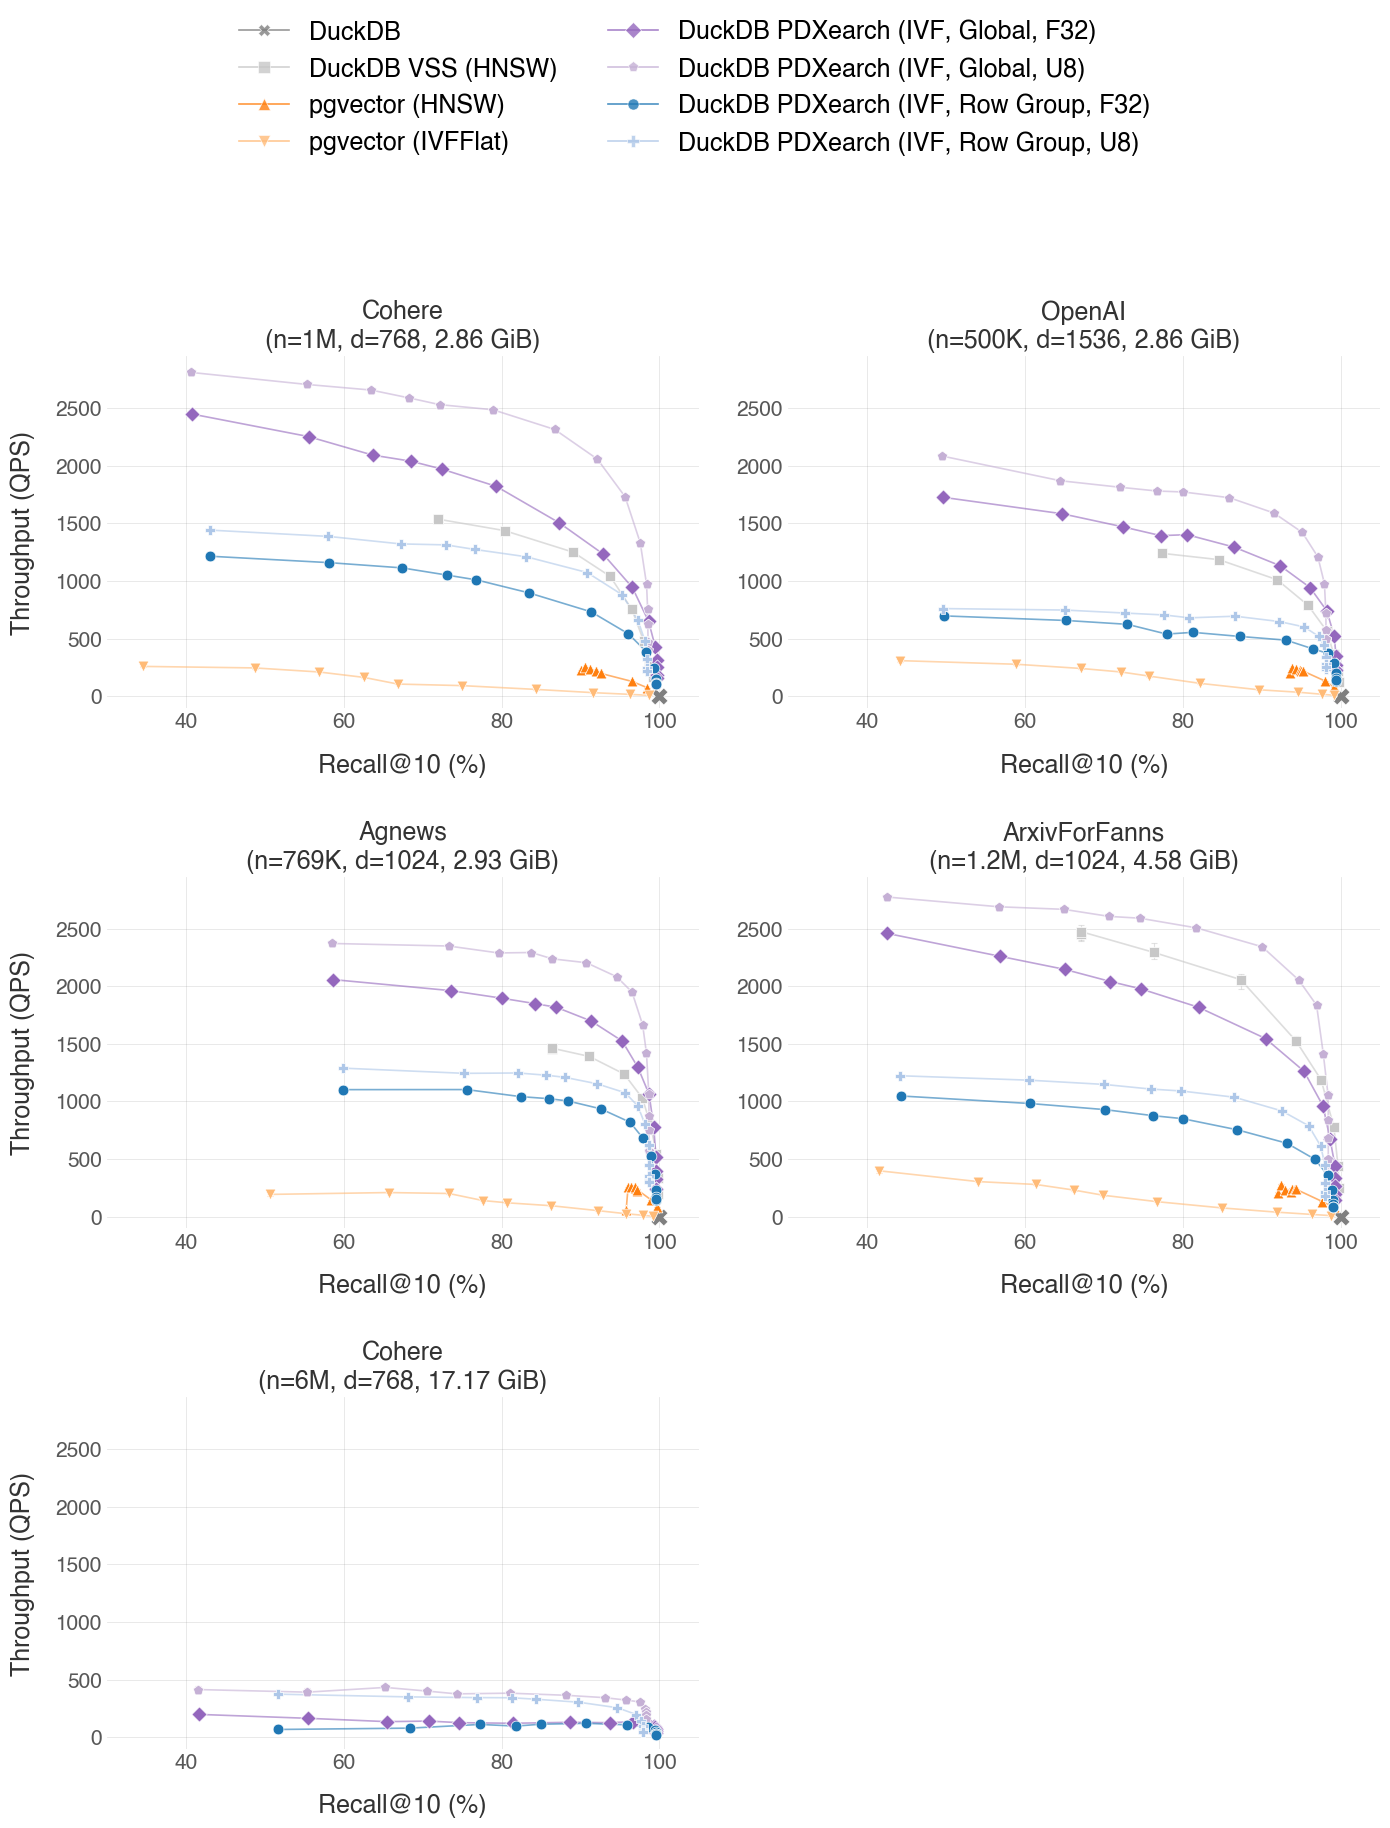

Saved index_search_blob_single_thread.pdf


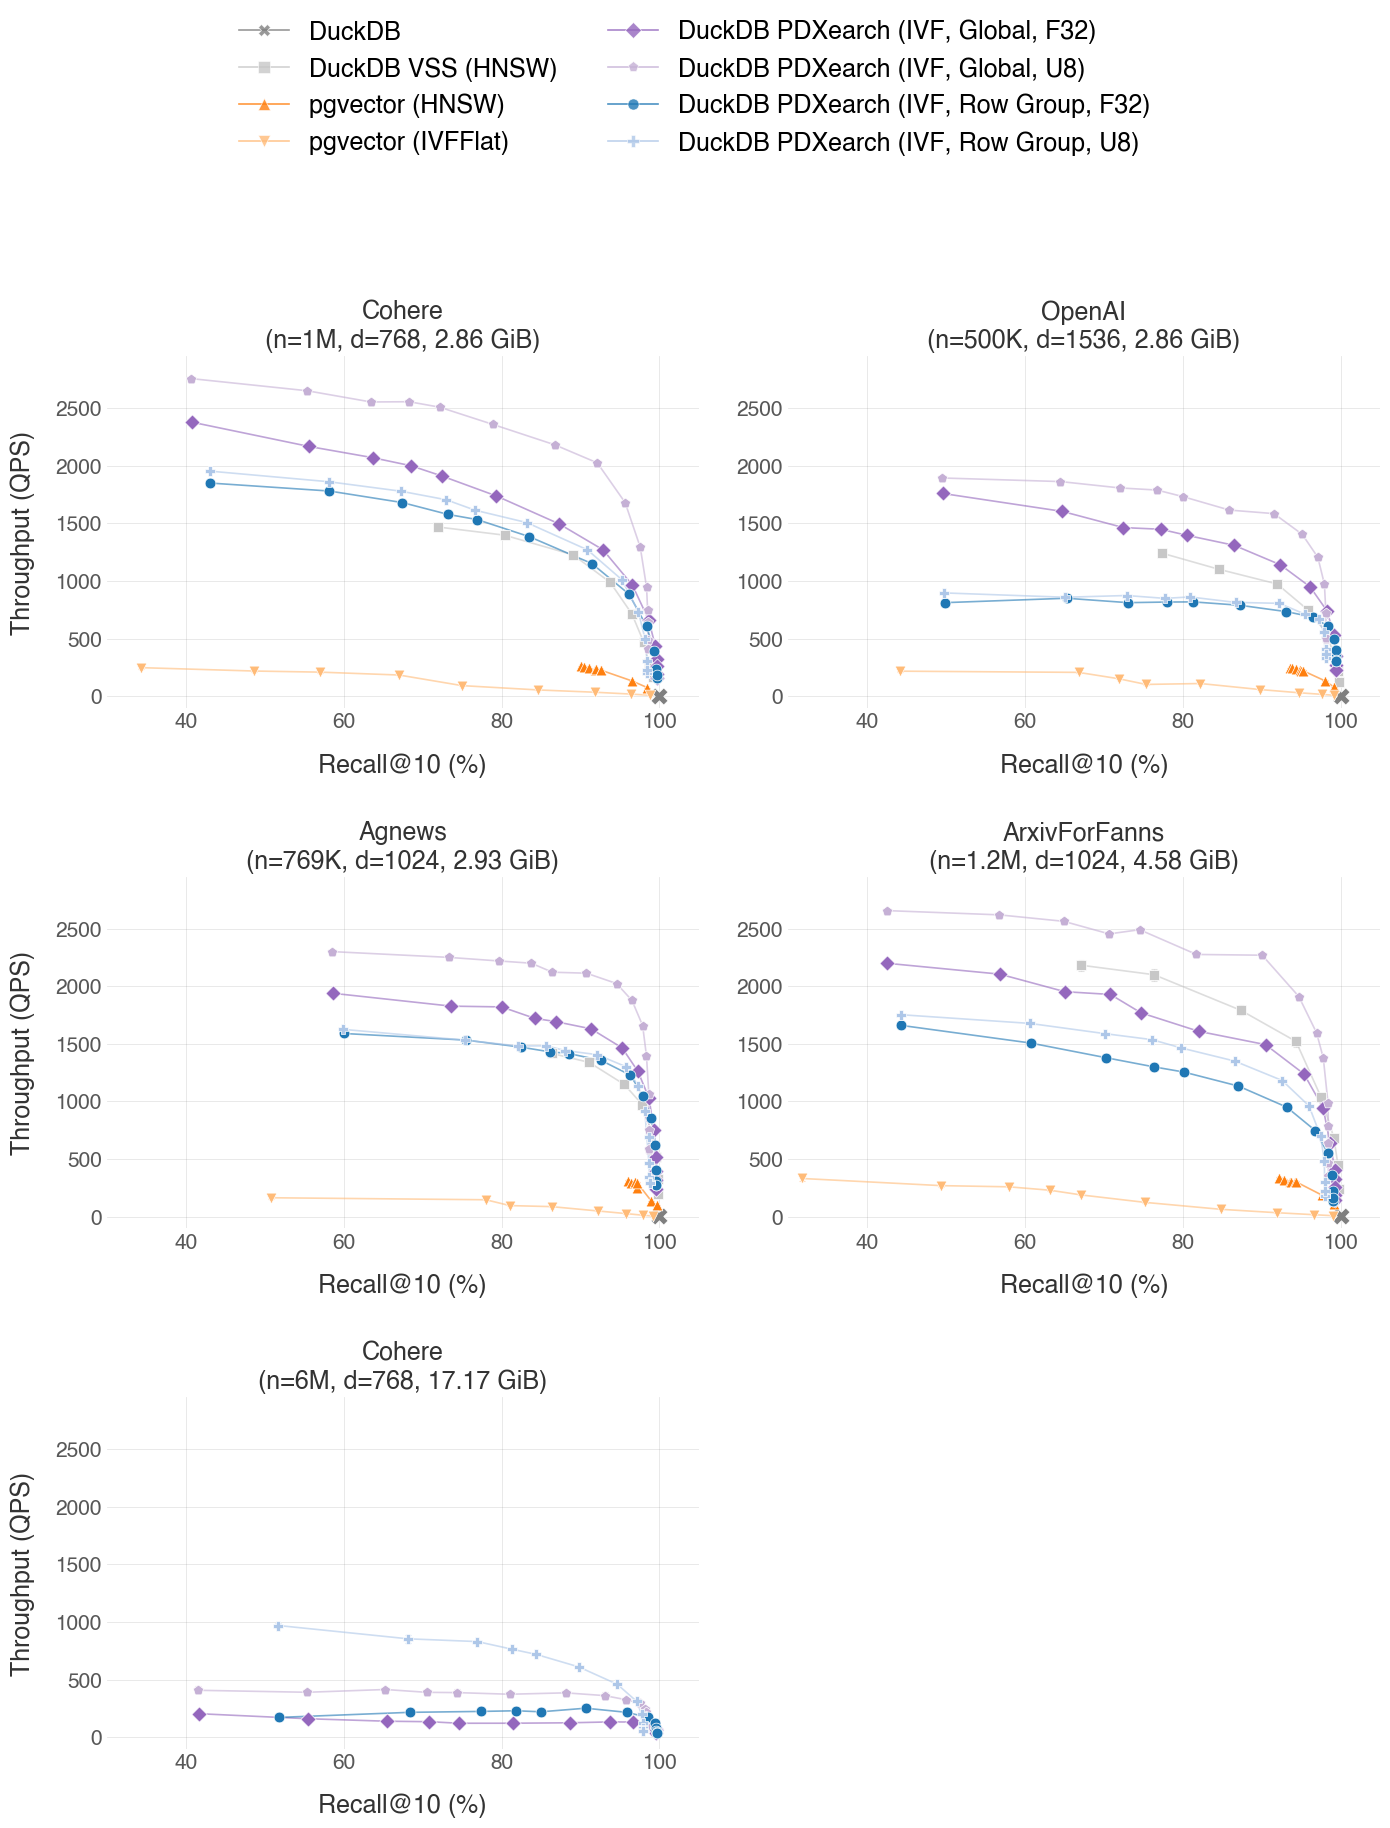

Saved index_search_blob_multi_thread.pdf


In [4]:
# ---------------------------------------------------------------------------
# 3. Scatter plot: Recall vs QPS, one subplot per dataset
#    Separate figures for single-thread (threads=1) vs multi-thread (threads>1)
# ---------------------------------------------------------------------------
from collections import defaultdict
import re
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

apply_style()

# Filter records to only include active (non-excluded) datasets
active_records = [r for r in records if r["dataset"] in set(datasets)]


def compute_shared_ylims(all_records, datasets):
    """Compute a single shared y-axis limit from *all* records (all datasets share the same scale)."""
    all_qps = [r["serial_qps"] for r in all_records]
    y_max = max(all_qps) if all_qps else 1
    shared_ylim = (-0.05, y_max * 1.05)
    return {ds: shared_ylim for ds in datasets}


shared_ylims = compute_shared_ylims(active_records, datasets)


def plot_recall_vs_qps(subset_records, datasets, filename, suptitle=None, ylims=None):
    """Plot Recall vs QPS scatter with one subplot per dataset, saving to *filename*."""
    grouped: dict[str, dict[str, list[tuple[float, float]]]] = defaultdict(lambda: defaultdict(list))
    for r in subset_records:
        grouped[r["dataset"]][r["index"]].append((r["recall"], r["serial_qps"], r["serial_qps_lo"], r["serial_qps_hi"], r.get("point_id", -1)))

    present_datasets = [ds for ds in datasets if grouped[ds]]
    if not present_datasets:
        print(f"No data for {filename}, skipping.")
        return

    all_index_types = set()
    for dataset in present_datasets:
        all_index_types.update(grouped[dataset].keys())
    all_index_types = [idx for idx in INDEX_ORDER if idx in all_index_types]

    n_datasets = len(present_datasets)
    n_cols = min(n_datasets, 2)
    n_rows = (n_datasets + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows), squeeze=False)

    for ds_idx, dataset in enumerate(present_datasets):
        row, col = divmod(ds_idx, n_cols)
        ax = axes[row][col]

        for index_type in all_index_types:
            points = grouped[dataset].get(index_type, [])
            if not points:
                continue

            points.sort(key=lambda p: p[0])
            recalls = [p[0] for p in points]
            qps_vals = [p[1] for p in points]
            qps_lo = [p[2] for p in points]
            qps_hi = [p[3] for p in points]
            point_ids = [p[4] for p in points]

            color = index_colors.get(index_type, "#808080")
            marker = index_markers.get(index_type, "o")

            ax.errorbar(recalls, qps_vals, yerr=[qps_lo, qps_hi], fmt="none",
                       ecolor=color, elinewidth=0.8, capsize=2, capthick=0.8, alpha=0.5, zorder=3)
            ms = MARKER_SIZE * 2.5 if index_type == "DuckDB" else MARKER_SIZE
            ax.scatter(recalls, qps_vals, label=index_type, color=color,
                       marker=marker, s=ms, zorder=3, edgecolors="white", linewidths=0.5)
            ax.plot(recalls, qps_vals, color=color, linewidth=1.2, alpha=0.6, zorder=2)
            if ANNOTATE_POINT_IDS:
                for _r, _q, _pid in zip(recalls, qps_vals, point_ids):
                    ax.annotate(str(_pid), (_r, _q), fontsize=5, ha="left", va="bottom",
                                color="#333333", xytext=(3, 3), textcoords="offset points", zorder=10)

        ax.set_title(format_dataset_title(dataset), fontsize=TITLE_FONTSIZE, color=FONT_COLOR)
        ax.set_xlabel("Recall@10 (%)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)
        if col == 0:
            ax.set_ylabel("Throughput (QPS)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)

        ax.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
        ax.set_axisbelow(True)

        ax.set_xticks([i / 5 for i in range(6)])
        # ax.set_xticks([0.60, 0.70, 0.80, 0.90, 1.00])

        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x * 100:.0f}"))

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        # ax.set_xlim(-0.05, 1.05)
        ax.set_xlim(0.30, 1.05)
        # ax.set_xlim(0.60, 1.00)
        if ylims and dataset in ylims:
            ax.set_ylim(-100, ylims[dataset][1])

        ax.tick_params(axis='both', colors=TICK_FONTS_COLOR, length=0)
        ax.tick_params(axis='x', labelsize=TICK_FONTSIZE)
        ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

    for idx in range(n_datasets, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].set_visible(False)

    legend_handles = []
    for index_type in all_index_types:
        color = index_colors.get(index_type, "#808080")
        marker = index_markers.get(index_type, "o")
        legend_handles.append(Line2D([0], [0], color=color, marker=marker, linestyle='-',
                                      markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                                      linewidth=1.2, alpha=0.8, label=index_type))

    fig.legend(handles=legend_handles, loc="upper center", ncol=math.ceil(len(all_index_types) / 4),
               frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.02))

    # if suptitle:
    #     fig.suptitle(suptitle, fontsize=TITLE_FONTSIZE + 2, color=FONT_COLOR, y=0.79)

    fig.tight_layout(rect=[0, 0, 1, 0.86])
    fig.subplots_adjust(wspace=0.15, hspace=0.48)
    save_fig(filename.removesuffix(".pdf"))
    plt.show()
    print(f"Saved {filename}")


records_single = [r for r in active_records if r["threads"] == 1]
records_multi = [r for r in active_records if r["threads"] > 1]

print(f"Single-thread records: {len(records_single)}, Multi-thread records: {len(records_multi)}")

plot_recall_vs_qps(records_single, datasets, "index_search_blob_single_thread.pdf",
                   suptitle="1 Thread/Worker", ylims=shared_ylims)
plot_recall_vs_qps(records_multi, datasets, "index_search_blob_multi_thread.pdf",
                   suptitle="14 Threads/Workers", ylims=shared_ylims)

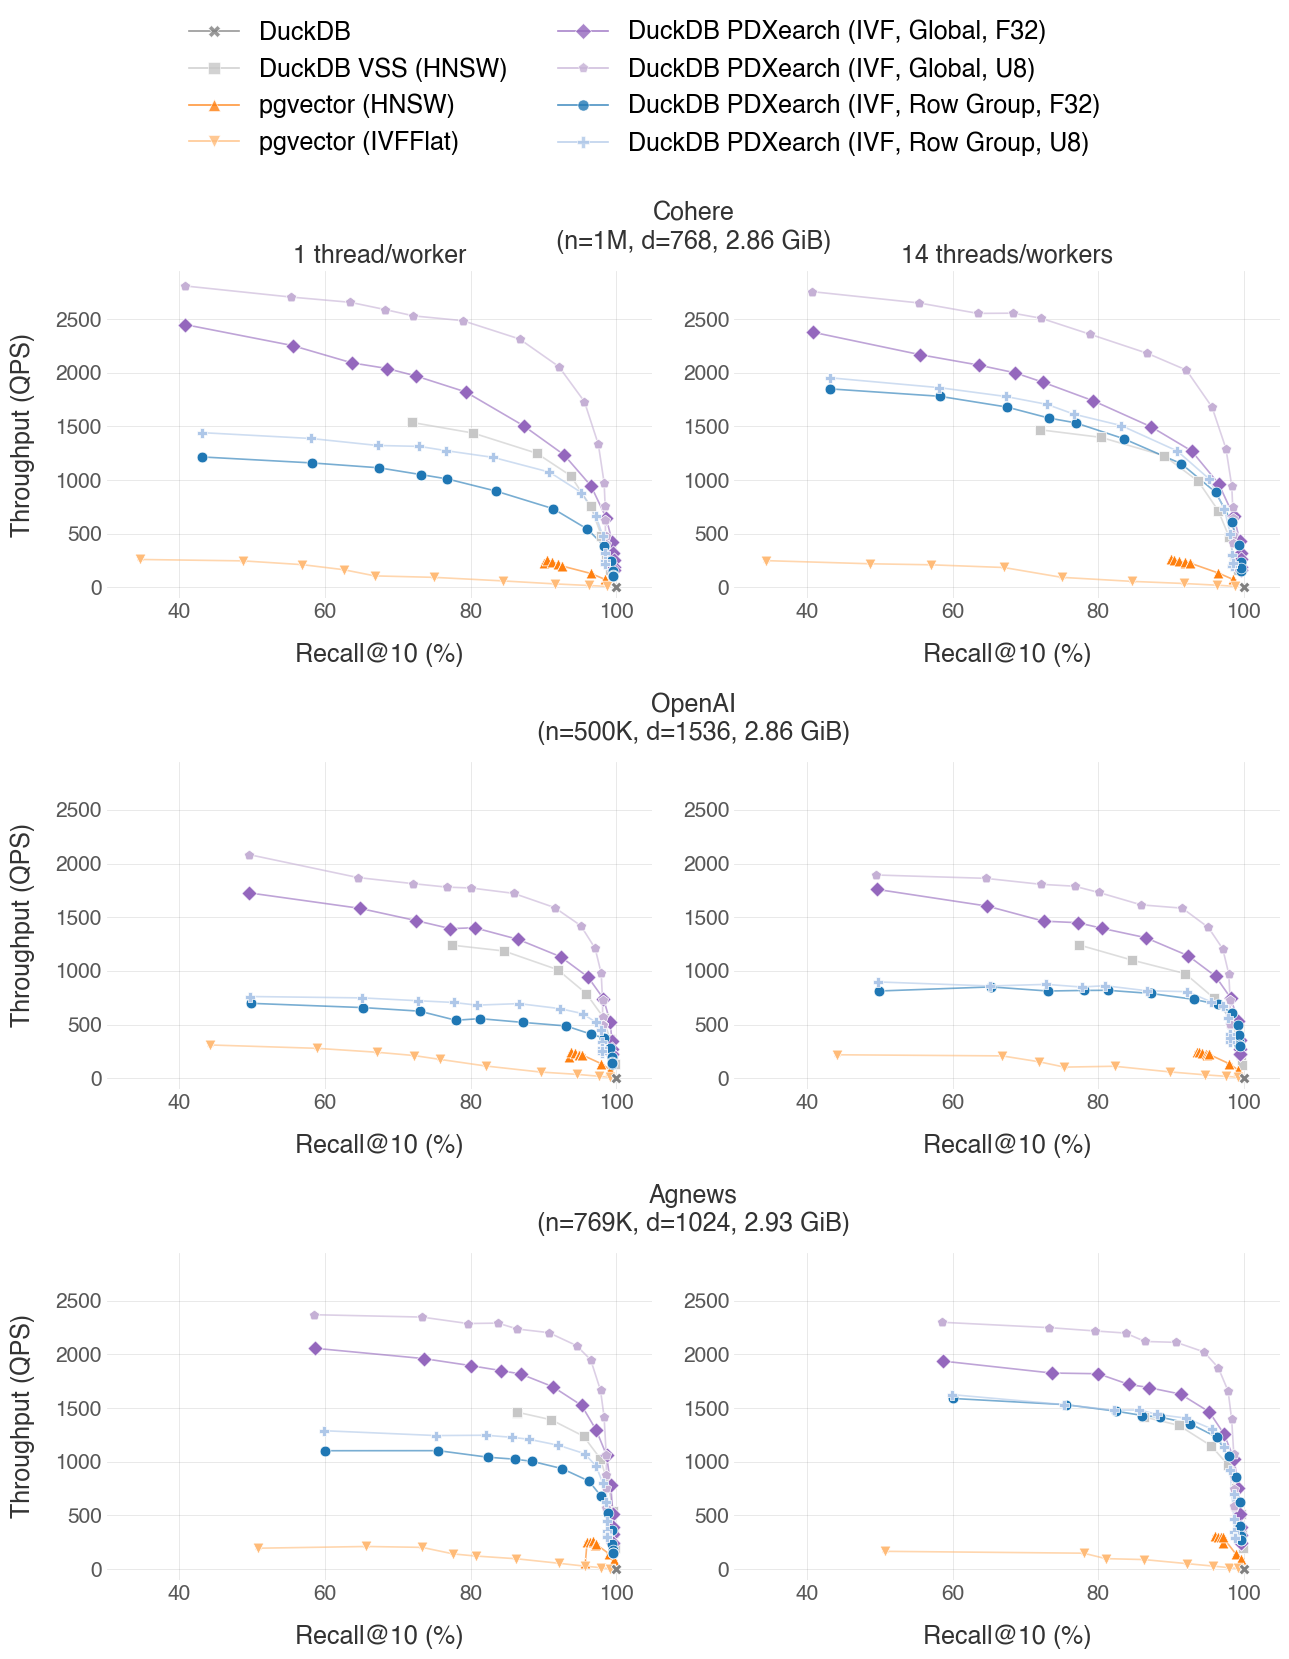

Saved index_search_blob_combined_1.pdf


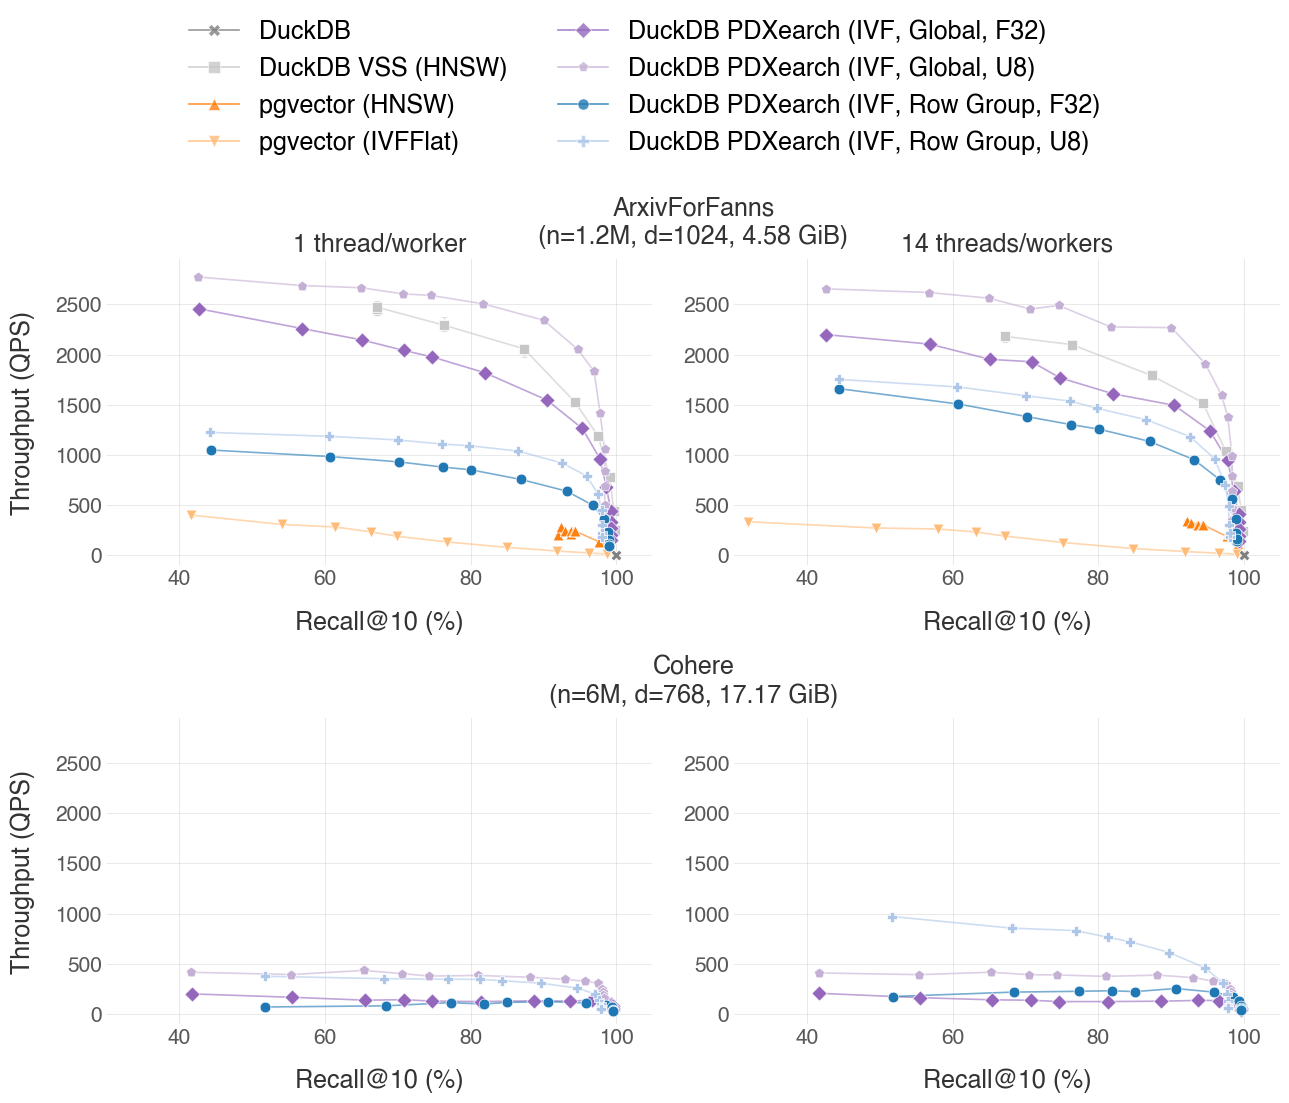

Saved index_search_blob_combined_2.pdf


In [5]:
# ---------------------------------------------------------------------------
# 4. Combined side-by-side: single-thread (left) vs multi-thread (right)
#    Split into two figures: first 3 datasets, then remaining datasets.
# ---------------------------------------------------------------------------
apply_style()

thread_groups = [
    ("1 thread/worker", records_single),
    ("14 threads/workers", records_multi),
]

# Build grouped data for each thread group
grouped_by_thread: list[dict[str, dict[str, list[tuple[float, float]]]]] = []
all_index_types_combined = set()
for _, recs in thread_groups:
    g: dict[str, dict[str, list[tuple[float, float]]]] = defaultdict(lambda: defaultdict(list))
    for r in recs:
        g[r["dataset"]][r["index"]].append((r["recall"], r["serial_qps"], r["serial_qps_lo"], r["serial_qps_hi"], r.get("point_id", -1)))
    grouped_by_thread.append(g)
    for ds in datasets:
        all_index_types_combined.update(g[ds].keys())
all_index_types_combined = [idx for idx in INDEX_ORDER if idx in all_index_types_combined]

# Shared legend handles (computed once, reused for both figures)
legend_handles = []
for index_type in all_index_types_combined:
    color = index_colors.get(index_type, "#808080")
    marker = index_markers.get(index_type, "o")
    legend_handles.append(Line2D([0], [0], color=color, marker=marker, linestyle='-',
                                  markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                                  linewidth=1.2, alpha=0.8, label=index_type))


def plot_combined(plot_datasets, filename, tight_layout_top=0.94):
    """Plot side-by-side 1T vs 14T for the given list of datasets."""
    n_rows = len(plot_datasets)
    n_cols = len(thread_groups)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 5.5 * n_rows), squeeze=False)

    for col_idx, (col_title, _) in enumerate(thread_groups):
        grouped = grouped_by_thread[col_idx]

        for row_idx, dataset in enumerate(plot_datasets):
            ax = axes[row_idx][col_idx]

            for index_type in all_index_types_combined:
                points = grouped[dataset].get(index_type, [])
                if not points:
                    continue
                points.sort(key=lambda p: p[0])
                recalls = [p[0] for p in points]
                qps_vals = [p[1] for p in points]
                qps_lo = [p[2] for p in points]
                qps_hi = [p[3] for p in points]
                point_ids = [p[4] for p in points]

                z_scatter = 10 if index_type == "DuckDB" else 3
                z_line = 9 if index_type == "DuckDB" else 2

                color = index_colors.get(index_type, "#808080")
                marker = index_markers.get(index_type, "o")

                ax.errorbar(recalls, qps_vals, yerr=[qps_lo, qps_hi], fmt="none",
                           ecolor=color, elinewidth=0.8, capsize=2, capthick=0.8, alpha=0.5, zorder=z_scatter)
                # ms = MARKER_SIZE * 2.5 if index_type == "DuckDB" else MARKER_SIZE
                ms = MARKER_SIZE
                ax.scatter(recalls, qps_vals, label=index_type, color=color,
                           marker=marker, s=ms, zorder=z_scatter, edgecolors='white', linewidths=0.5)
                ax.plot(recalls, qps_vals, color=color, linewidth=1.2, alpha=0.6, zorder=z_line)
                if ANNOTATE_POINT_IDS:
                    for _r, _q, _pid in zip(recalls, qps_vals, point_ids):
                        ax.annotate(str(_pid), (_r, _q), fontsize=5, ha="left", va="bottom",
                                    color="#333333", xytext=(3, 3), textcoords="offset points", zorder=10)

            # Column header (thread count) only on the first row
            if row_idx == 0:
                ax.set_title(col_title, fontsize=TITLE_FONTSIZE, color=FONT_COLOR)

            ax.set_xlabel("Recall@10 (%)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)
            if col_idx == 0:
                ax.set_ylabel("Throughput (QPS)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)

            ax.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
            ax.set_axisbelow(True)
            for spine in ax.spines.values():
                spine.set_visible(False)

            if dataset in shared_ylims:
                ax.set_ylim(-100, shared_ylims[dataset][1])
            # ax.set_xticks([0.60, 0.70, 0.80, 0.90, 1.00])
            # ax.set_xlim(0.60, 1.00)
            ax.set_xticks([i / 5 for i in range(6)])
            ax.set_xlim(0.30, 1.05)
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x * 100:.0f}"))

            ax.tick_params(axis='both', colors=TICK_FONTS_COLOR, length=0)
            ax.tick_params(axis='x', labelsize=TICK_FONTSIZE)
            ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

    fig.legend(handles=legend_handles, loc="upper center",
               ncol=math.ceil(len(all_index_types_combined) / 4),
               frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.01))

    fig.tight_layout(rect=[0, 0, 1, tight_layout_top])
    fig.subplots_adjust(wspace=0.15, hspace=0.50)

    # Add shared dataset titles centered above each row of subplots.
    for row_idx, dataset in enumerate(plot_datasets):
        ax_left = axes[row_idx][0]
        ax_right = axes[row_idx][n_cols - 1]
        left_bbox = ax_left.get_position()
        right_bbox = ax_right.get_position()
        x_center = (left_bbox.x0 + right_bbox.x1) / 2
        y_top = max(left_bbox.y1, right_bbox.y1)
        fig.text(x_center, y_top + 0.010, format_dataset_title(dataset),
                 ha="center", va="bottom", fontsize=TITLE_FONTSIZE, color=FONT_COLOR)

    save_fig(filename)
    plt.show()
    print(f"Saved {filename}.pdf")


# First 3 datasets, then last 2
plot_combined(datasets[:3], "index_search_blob_combined_1", tight_layout_top=0.87)
plot_combined(datasets[3:], "index_search_blob_combined_2", tight_layout_top=0.81)

In [6]:
# ---------------------------------------------------------------------------
# 5. QPS decrease (Global -> Row Group) at the 90% recall target.
#    Per dataset, per thread count (1 and 14): take each system's first
#    measurement with recall >= 90%, then compute the percentage QPS
#    decrease going from the Global to the Row Group approach.
#    The recall actually achieved by each selected point is shown too.
# ---------------------------------------------------------------------------
RECALL_TARGET = 0.90
GLOBAL_INDEX = "DuckDB PDXearch (IVF, Global, F32)"
ROWGROUP_INDEX = "DuckDB PDXearch (IVF, Row Group, F32)"


def first_point_at_recall(recs, index_name, threads, target=RECALL_TARGET):
    """Return (recall, qps) of the first (lowest-recall) measurement at/above target.

    Measurements are sorted by recall ascending and the first one with
    recall >= target is selected. Returns None if no measurement qualifies.
    """
    candidates = [
        r for r in recs
        if r["index"] == index_name and r["threads"] == threads and r["recall"] >= target
    ]
    if not candidates:
        return None
    best = min(candidates, key=lambda r: r["recall"])
    return best["recall"], best["serial_qps"]


print(f"QPS decrease from Global to Row Group at >= {RECALL_TARGET:.0%} recall\n")
header = (f"{'Dataset':28s} {'Threads':>7s} "
          f"{'Global recall':>13s} {'Global QPS':>12s} "
          f"{'RowGrp recall':>13s} {'RowGrp QPS':>12s} {'QPS decrease':>13s}")
print(header)
print("-" * len(header))

for dataset in datasets:
    ds_recs = [r for r in active_records if r["dataset"] == dataset]
    for threads in (1, 14):
        global_point = first_point_at_recall(ds_recs, GLOBAL_INDEX, threads)
        rowgroup_point = first_point_at_recall(ds_recs, ROWGROUP_INDEX, threads)

        if global_point is None or rowgroup_point is None:
            missing = []
            if global_point is None:
                missing.append("Global")
            if rowgroup_point is None:
                missing.append("Row Group")
            note = f"(no {' & '.join(missing)} point >= {RECALL_TARGET:.0%} recall)"
            print(f"{dataset:28s} {threads:>7d} {note}")
            continue

        global_recall, global_qps = global_point
        rowgroup_recall, rowgroup_qps = rowgroup_point

        # Percentage decrease in QPS going Global -> Row Group.
        # Positive means Row Group is slower than Global.
        pct_decrease = (global_qps - rowgroup_qps) / global_qps * 100
        print(f"{dataset:28s} {threads:>7d} "
              f"{global_recall * 100:>12.2f}% {global_qps:>12.1f} "
              f"{rowgroup_recall * 100:>12.2f}% {rowgroup_qps:>12.1f} {pct_decrease:>12.1f}%")


QPS decrease from Global to Row Group at >= 90% recall

Dataset                      Threads Global recall   Global QPS RowGrp recall   RowGrp QPS  QPS decrease
--------------------------------------------------------------------------------------------------------
Cohere (1M × 768)                  1        92.85%       1235.2        91.36%        732.7         40.7%
Cohere (1M × 768)                 14        92.85%       1271.3        91.44%       1151.7          9.4%
OpenAI (500K × 1536)               1        92.38%       1132.0        93.11%        487.4         56.9%
OpenAI (500K × 1536)              14        92.38%       1141.1        93.15%        734.6         35.6%
Agnews (769K × 1024)               1        91.34%       1698.1        92.58%        936.1         44.9%
Agnews (769K × 1024)              14        91.34%       1630.0        92.63%       1355.8         16.8%
ArxivForFanns (1.2M × 1024)        1        90.50%       1546.1        93.22%        637.8         58.7%